## Notebook to build familiarity with Single Neuron Reconstructions

In [1]:
%matplotlib inline

import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from multiprocessing import Pool
from tqdm import tqdm


In [2]:
def euclidean_distance(node1, node2):
    """
    Calculate the Euclidean distance between two nodes.

    Parameters:
    node1, node2 (dict): Nodes with 'pos' key containing x, y, z coordinates.

    Returns:
    float: Euclidean distance between node1 and node2.
    """
    pos1 = np.array(node1['pos'])
    pos2 = np.array(node2['pos'])
    return np.linalg.norm(pos1 - pos2)

def add_node_to_graph(graph, node):
    """
    Add a node with attributes to the graph.

    Parameters:
    graph (nx.DiGraph): The graph to which the node will be added.
    node (dict): Node data.
    """
    graph.add_node(
        node['sampleNumber'], 
        pos=(node['x'], node['y'], node['z']), 
        radius=node['radius'], 
        structure_id=node['structureIdentifier'],
        allen_id=node['allenId']
    )

def add_edge_to_graph(graph, parent, child):
    """
    Add an edge between parent and child nodes in the graph, with weight as Euclidean distance.

    Parameters:
    graph (nx.DiGraph): The graph to which the edge will be added.
    parent, child (int): The sampleNumbers of the parent and child nodes.
    """
    graph.add_edge(
        parent, 
        child, 
        weight=euclidean_distance(
            graph.nodes()[parent],
            graph.nodes()[child]
        )
    )


def json_to_digraph(file_path):
    """
    Load a neuronal reconstruction from a JSON file into a NetworkX graph.

    The JSON file contains SWC data with additional brain region information for each node.
    The graph will be a directed tree.

    Parameters:
    file_path (str): Path to the JSON file containing reconstruction data.

    Returns:
    nx.DiGraph: A directed graph representing the neuronal tree.
    """
    try:
        with open(file_path, 'r') as file:
            data = json.load(file)
    except IOError as e:
        print(f"Error opening file: {e}")
        return None

    # Certain JSON files may have a single 'neuron' object instead of a 'neurons' array
    neuron_data = data['neuron'] if 'neuron' in data else data['neurons'][0]

    axon_graph, dendrite_graph = nx.DiGraph(), nx.DiGraph()

    for structure, graph in [('dendrite', dendrite_graph), ('axon', axon_graph)]:
        if structure not in neuron_data:
            # Some reconstructions may be missing an axon or dendrite tracing
            print(f"Missing structure {structure} for {file_path}")
            continue
        for node in sorted(neuron_data[structure], key=lambda x: x['sampleNumber']):
            add_node_to_graph(graph, node)
            if node['parentNumber'] != -1:
                add_edge_to_graph(graph, node['parentNumber'], node['sampleNumber'])
                
    if dendrite_graph.nodes() and axon_graph.nodes():
        # Remove duplicate soma node from axon graph
        axon_graph.remove_node(1)  

    # The sampleNumber starts at 1 for both axon and dendrite, so 
    # relabel axon nodes to avoid key collisions when merging the graphs,.
    first_axon_label = max(dendrite_graph.nodes()) + 1 if dendrite_graph.nodes() else 1
    joined_graph = nx.union(
        dendrite_graph, 
        nx.convert_node_labels_to_integers(
            axon_graph, 
            first_label=first_axon_label
        )
    )
    roots = [n for n in joined_graph if joined_graph.in_degree(n) == 0]
    # Link the dendrite to the axon
    if len(roots) == 2:
        add_edge_to_graph(joined_graph, roots[0], roots[1])

    return joined_graph

In [3]:
# file_path = "../data/mouselight_reconstructions/AA0001.json"
file_path = "../data/exaSPIM_653158_2023-06-01_20-41-38_reconstructions/Complete_annotated/N004-653158-consensus.json"

# Load the neuronal tree into a NetworkX graph
graph = json_to_digraph(file_path)

In [4]:
# vars(graph)

In [5]:
# list(graph.edges(data=True))

In [6]:
# np.unique(collectIDs)
ccf_structures = pd.read_csv('/data/allen_mouse_ccf/annotation/adult_mouse_ccf_structures.csv')
acronym_to_id = ccf_structures.set_index('acronym')['id'].to_dict()
id_to_acronym = {id: acronym for acronym, id in acronym_to_id.items()}
id_to_acronym[-9223372036854775808] = 'NaN' # fix for nan values (as ints)

In [7]:
listNodes = list(graph.nodes(data=True))
nNodes = len(listNodes)
collectIDs = np.empty(nNodes) # change dtype
collectAcronyms = np.empty(nNodes, dtype =object)
for i in range(nNodes):
    collectIDs[i] = listNodes[i][1]["allen_id"]
    collectAcronyms[i] = id_to_acronym[collectIDs[i].astype(int)]

/tmp/ipykernel_70/4067037319.py:7: RuntimeWarning: invalid value encountered in cast
  collectAcronyms[i] = id_to_acronym[collectIDs[i].astype(int)]


<Axes: >

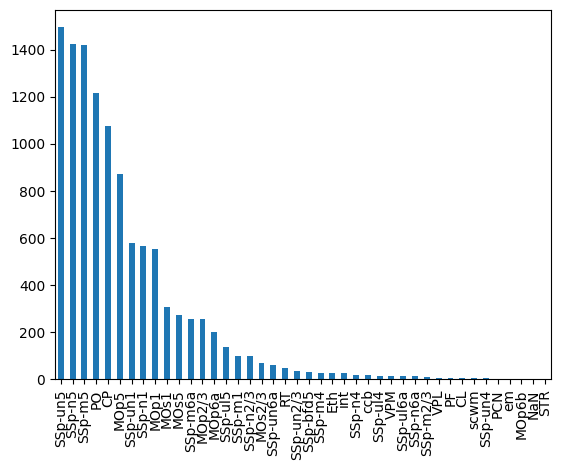

In [8]:
pd.Series(collectAcronyms).value_counts(sort=True).plot(kind='bar')

In [9]:
id_to_acronym[collectIDs[0].astype(int)]

'PO'

In [10]:
# Define a function for filtering the graph based on attribute values
def get_subgraph(G, attribute, values):
    """
    Extract a subgraph from the given graph based on specified attribute values.

    Parameters:
    G (nx.Graph): The original graph from which to extract the subgraph.
    attribute (str): The node attribute used for filtering.
    values (tuple): A tuple of attribute values to include in the subgraph.

    Returns:
    nx.Graph: A subgraph of G containing only nodes with the specified attribute values.
    """
    filtered_nodes = [node for node, attr in G.nodes(data=True) if attr.get(attribute) in values]
    return G.subgraph(filtered_nodes)

attribute = "structure_id"
axon = get_subgraph(graph, attribute, (2,))
dendrite = get_subgraph(graph, attribute, (1, 3))

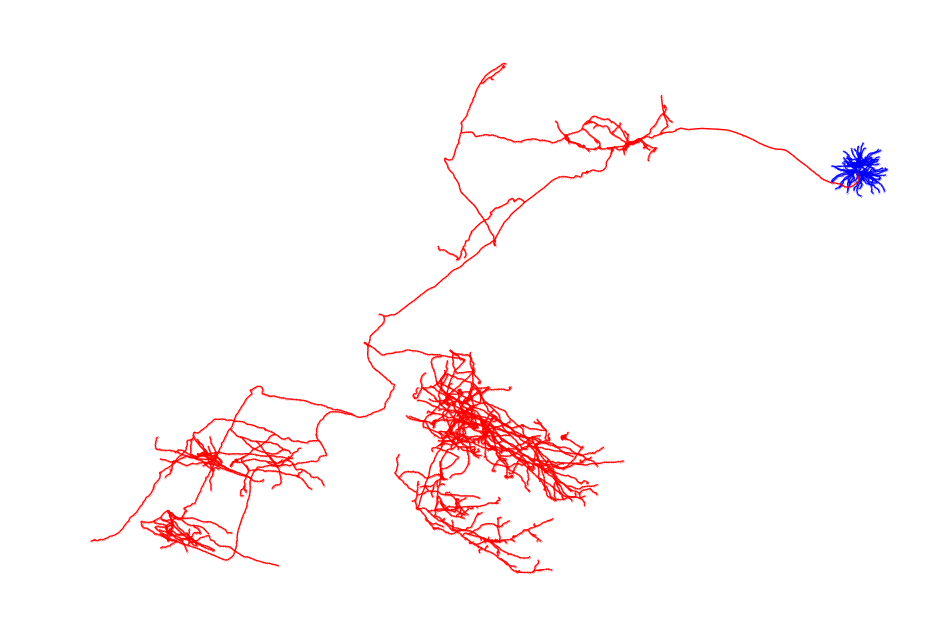

In [11]:
def plot_graph_2d(graph, ax, color="blue", node_size=0.01, width=1):
    """
    Generate a 2D plot of a neuronal tree graph using matplotlib.

    Parameters:
    graph (nx.DiGraph): A directed graph representing the neuronal tree.
    """
    # Extracting node positions
    pos = {node: data['pos'][:2] for node, data in graph.nodes(data=True)}

    nx.draw(
        graph, 
        pos,
        ax=ax,
        arrows=False,
        width=width,
        with_labels=False, 
        node_size=node_size, 
        node_color=color,
        edge_color=color
    )
    
    
fig, ax = plt.subplots(figsize=(12, 8))

plot_graph_2d(dendrite, ax, "blue")
plot_graph_2d(axon, ax, "red")

plt.show()

In [12]:
def load_graphs(filepaths):
    """
    Load all JSON files in the given directory as graphs using multiprocessing.

    Parameters:
    directory_path (str): Path to the directory containing JSON files.

    Returns:
    list of nx.Graph: A list of graphs loaded from the JSON files.
    """
    # Use multiprocessing pool to load graphs in parallel
    with Pool() as pool:
        graphs = list(tqdm(pool.imap(json_to_digraph, filepaths), total=len(filepaths)))

    # Remove None values from the list in case there were errors
    return [graph for graph in graphs if graph is not None]


def get_cells_in_regions(manifest_path, acronyms):
    # Load the CSV file
    df = pd.read_csv(manifest_path)

    # If a single acronym is provided, convert it to a list
    if isinstance(acronyms, str):
        acronyms = [acronyms]

    # Filter the dataframe for the specified acronyms and get the filenames
    filtered_df = df[df['soma_acronym'].isin(acronyms)]
    filenames = filtered_df['filename'].tolist()
    filtered_acronyms = filtered_df['soma_acronym'].tolist()

    return filenames, filtered_acronyms

In [13]:
manifest_path = "../scratch/reconstructed_neurons.csv"
paths, acronyms = get_cells_in_regions(manifest_path, ['TH', 'MD', 'PCN', 'PVT', 'VAL', 'CM', 'RE', 'IMD', 'CL', 'PT'])
graphs = load_graphs(paths)

  0%|          | 0/98 [00:00<?, ?it/s]

Missing structure dendrite for /data/exaSPIM_653158_2023-06-01_20-41-38_reconstructions/Complete_annotated/N011-653158-PL.json
Missing structure dendrite for /data/exaSPIM_653980_2023-08-10_20-08-29_reconstructions/Complete_annotated/N014-653980-CA.json


100%|██████████| 98/98 [00:10<00:00,  9.50it/s]


In [14]:
np.unique(acronyms)

array(['CL', 'CM', 'MD', 'PCN', 'RE', 'TH', 'VAL'], dtype='<U3')

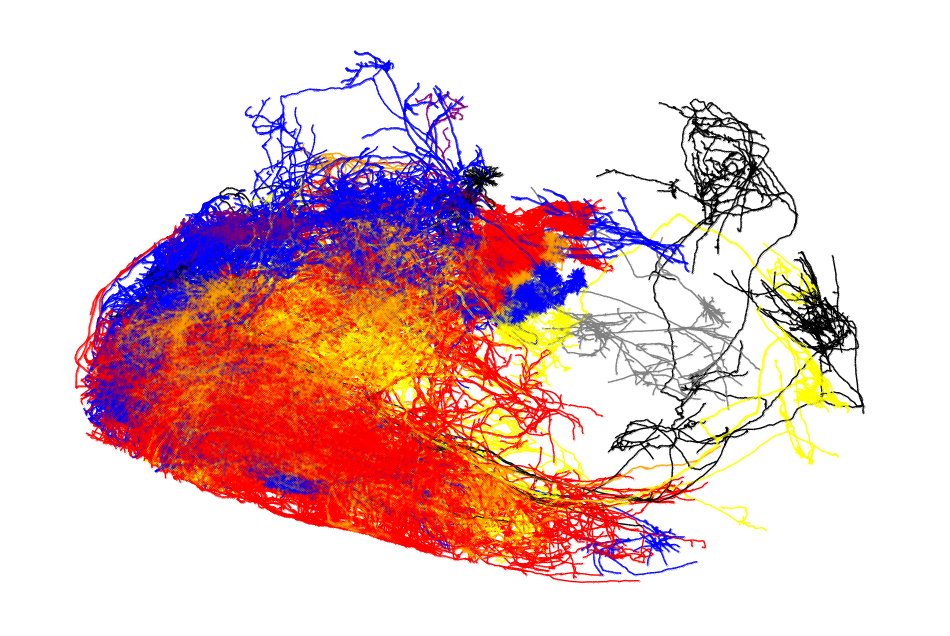

In [15]:
# graphs
colorDict = {'TH':"gray",
             'MD':"blue",
             'PCN':"orange",
             'PVT':"green",
             'VAL':"red",
             'CM':"purple",
             'RE':"black",
             'IMD':"yellow",
             'CL':"yellow",
             'PT':"yellow"}
fig, ax = plt.subplots(figsize=(12, 8))

for i in range(98):
    acr = acronyms[i]
    plot_graph_2d(graphs[i], ax, colorDict[acr])
# plot_graph_2d(graphs[0], ax, "red")
# plot_graph_2d(graphs[1], ax, "blue")
# plt.show()

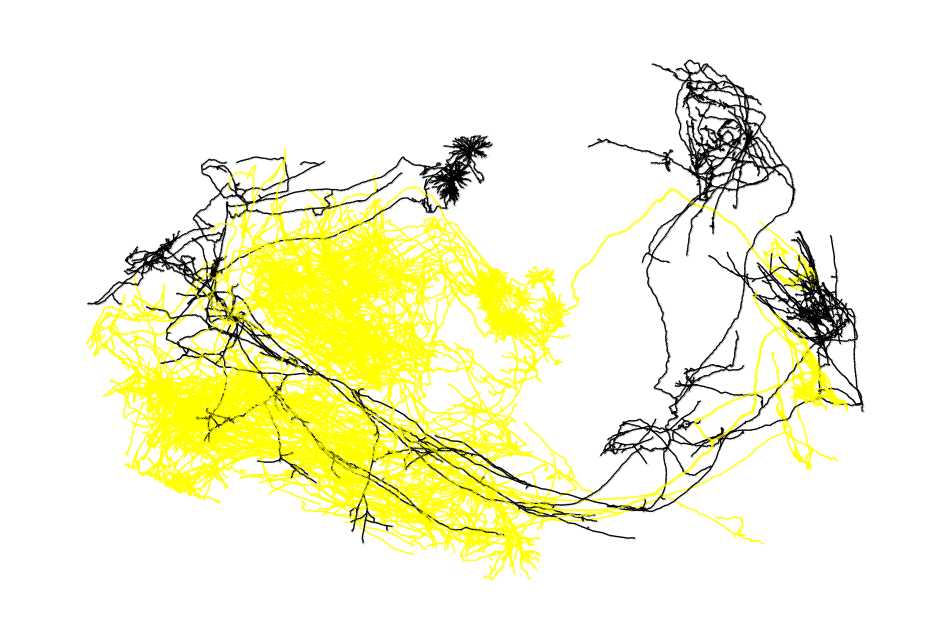

In [22]:
# graphs
colorDict = {'TH':"gray",
             'MD':"blue",
             'PCN':"orange",
             'PVT':"green",
             'VAL':"red",
             'CM':"purple",
             'RE':"black",
             'IMD':"yellow",
             'CL':"yellow",
             'PT':"yellow"}
fig, ax = plt.subplots(figsize=(12, 8))

for i in range(98):
    acr = acronyms[i]
    if acr == "VAL" or acr == "RE":
        plot_graph_2d(graphs[i], ax, colorDict[acr])
# plot_graph_2d(graphs[0], ax, "red")
# plot_graph_2d(graphs[1], ax, "blue")
# plt.show()

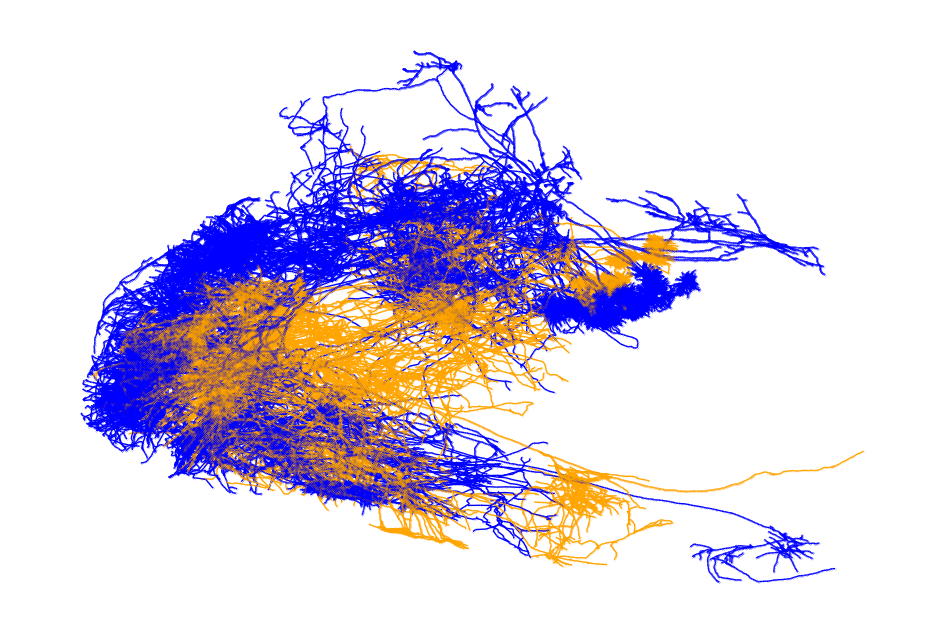

In [20]:
# graphs
colorDict = {'TH':"gray",
             'MD':"blue",
             'PCN':"orange",
             'PVT':"green",
             'VAL':"red",
             'CM':"purple",
             'RE':"black",
             'IMD':"yellow",
             'CL':"yellow",
             'PT':"yellow"}
fig, ax = plt.subplots(figsize=(12, 8))

for i in range(98):
    acr = acronyms[i]
    if acr == "PCN" or acr == "MD":
        plot_graph_2d(graphs[i], ax, colorDict[acr])
# plot_graph_2d(graphs[0], ax, "red")
# plot_graph_2d(graphs[1], ax, "blue")
# plt.show()

In [ ]:
def find_terminals(graph):
    """
    Find all terminal nodes in a graph. A terminal node is defined as a node with no children.

    Parameters:
    graph (nx.Graph): The graph to analyze.

    Returns:
    list: A list of nodes that are terminal nodes.
    """
    terminal_nodes = [node for node in graph.nodes() if graph.out_degree(node) == 0]
    return terminal_nodes

In [ ]:
# neuron_data = data['neuron'] if 'neuron' in data else data['neurons'][0]
# filePath = Path("data/mouselight_reconstructions/AA0458.json")
filePath = "../data/mouselight_reconstructions/AA1391.json"
f = open(filePath)
data = json.load(f)
# data
# neuron_data = data['neuron'] if 'neuron' in data else data['neurons'][0]
data["neuron"].keys()